# Jupyter notebook для оценки качества генерации текста (LLM Evaluation)

## Трек B: Text Summarization

В этом ноутбуке мы проведем оценку качества моделей суммаризации текста, используя датасет Gazeta и метрики ROUGE, BLEU, BERTScore.

**Примечание:** Для корректного запуска убедитесь, что выбрано ядро `.venv`.

In [19]:
# 1. Установка необходимых библиотек
# !pip install transformers datasets evaluate rouge_score bert_score sacremoses torch pandas matplotlib seaborn scipy

In [20]:
# 2. Импорт модулей и настройка окружения
import pandas as pd
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import evaluate
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [21]:
# 3. Загрузка датасета
# Используем датасет IlyaGusev/gazeta (новостные статьи и саммари)
try:
    dataset = load_dataset("IlyaGusev/gazeta", split="test[:20]", revision="v1.0") # Берем 20 примеров для скорости
except Exception as e:
    print(f"Ошибка загрузки v1.0, пробуем загрузить без ревизии: {e}")
    dataset = load_dataset("IlyaGusev/gazeta", split="test[:20]")

print(f"Размер выборки: {len(dataset)}")
print("\nПример данных:")
print(f"Текст: {dataset[0]['text'][:200]}...")
print(f"Саммари: {dataset[0]['summary'][:200]}...")

Using the latest cached version of the dataset since IlyaGusev/gazeta couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /home/zodiac/.cache/huggingface/datasets/IlyaGusev___gazeta/default/0.0.0/c4d8e46f79e17c4a864a320e6773436dc28fddd8 (last modified on Fri Jan 16 11:01:05 2026).


Размер выборки: 20

Пример данных:
Текст: На этих выходных в Берлине прошли крупные акции протеста против введенных для борьбы с коронавирусом ограничений. Демонстранты скандировали «Путин!» По словам депутата городской палаты представителей ...
Саммари: Протестующие против антикоронавирусных мер немцы скандировали имя российского президента, потому что уважают его. Такое мнение выразил депутат городской палаты представителей Гуннар Линдеманн. На этих...


In [22]:
# 4. Инициализация моделей
# Сравним две модели:
# 1. IlyaGusev/rut5_base_sum_gazeta (Специализированная на этом датасете)
# 2. cointegrated/rut5-base-multitask (Универсальная модель)

models = {}

print("Загрузка модели 1...")
model_name_1 = "IlyaGusev/rut5_base_sum_gazeta"
tokenizer_1 = AutoTokenizer.from_pretrained(model_name_1)
model_1 = AutoModelForSeq2SeqLM.from_pretrained(model_name_1).to(device)
models["rut5_gazeta"] = (model_1, tokenizer_1)

print("Загрузка модели 2...")
model_name_2 = "cointegrated/rut5-base-multitask"
tokenizer_2 = AutoTokenizer.from_pretrained(model_name_2)
model_2 = AutoModelForSeq2SeqLM.from_pretrained(model_name_2).to(device)
models["rut5_multitask"] = (model_2, tokenizer_2)

Загрузка модели 1...
Загрузка модели 2...


/home/zodiac/stadygit/LLM-Driven-Development/.venv/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [23]:
# 5. Определение функций для метрик качества
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")

def calculate_metrics_for_batch(predictions, references):
    # ROUGE
    rouge_res = rouge.compute(predictions=predictions, references=references)
    
    # BLEU
    bleu_res = bleu.compute(predictions=predictions, references=references)
    
    # BERTScore
    # Вычисляем для каждого, потом усредняем
    bert_res = bertscore.compute(predictions=predictions, references=references, lang="ru")
    bert_f1 = np.mean(bert_res["f1"])
    
    return {
        "ROUGE-1": rouge_res["rouge1"],
        "ROUGE-L": rouge_res["rougeL"],
        "BLEU": bleu_res["bleu"],
        "BERTScore": bert_f1
    }

In [24]:
# 6. Функция генерации
def generate_summary(model, tokenizer, text, prefix="", **kwargs):
    inputs = tokenizer(prefix + text, return_tensors="pt", max_length=1024, truncation=True).to(device)
    
    # Параметры генерации по умолчанию
    gen_kwargs = {
        "max_length": 200, 
        "min_length": 50, 
        "length_penalty": 2.0, 
        "num_beams": 4, 
        "early_stopping": True
    }
    
    # Обновляем параметры переданными аргументами (чтобы избежать дублирования)
    gen_kwargs.update(kwargs)
    
    start_time = time.time()
    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            **gen_kwargs
        )
    end_time = time.time()
    
    summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
    duration = end_time - start_time
    
    return summary, duration, len(summary)

In [25]:
# 7. Эксперимент 1: Сравнение моделей (Zero-shot)
# Для rut5_multitask нужен префикс для задачи суммаризации, обычно "summarize: " или "headline: "
# Но описание модели cointegrated/rut5-base-multitask говорит про "summarize" для заголовка, 
# а для упрощения попробуем 'summarize: '.

results = []

for name, (model, tokenizer) in models.items():
    print(f"Processing model: {name}")
    model_preds = []
    model_refs = []
    
    prefix = "summarize: " if "multitask" in name else ""
    
    for i, item in tqdm(enumerate(dataset), total=len(dataset)):
        text = item['text']
        reference = item['summary']
        
        summary, duration, length = generate_summary(model, tokenizer, text, prefix=prefix)
        
        model_preds.append(summary)
        model_refs.append(reference)
        
        results.append({
            "model": name,
            "experiment": "zero-shot",
            "duration": duration,
            "length": length,
            "prediction": summary,
            "reference": reference
        })
    
    # Вычисляем метрики для всей пачки
    metrics = calculate_metrics_for_batch(model_preds, model_refs)
    print(f"Metrics for {name}: {metrics}")
    
    # Дописываем метрики к каждому результату (для графика)
    # Можно хранить отдельно, но для таблицы результатов проще так
    for res in results:
        if res["model"] == name and res["experiment"] == "zero-shot":
            res.update(metrics)

Processing model: rut5_gazeta


100%|██████████| 20/20 [00:19<00:00,  1.01it/s]


Metrics for rut5_gazeta: {'ROUGE-1': np.float64(0.12545454545454543), 'ROUGE-L': np.float64(0.12499999999999999), 'BLEU': 0.10573147483809023, 'BERTScore': np.float64(0.7322980761528015)}
Processing model: rut5_multitask


100%|██████████| 20/20 [00:12<00:00,  1.65it/s]

Metrics for rut5_multitask: {'ROUGE-1': np.float64(0.17878787878787877), 'ROUGE-L': np.float64(0.16731601731601728), 'BLEU': 0.06625884819957106, 'BERTScore': np.float64(0.7169898808002472)}


In [26]:
# 8. Эксперимент 2: Влияние Гиперпараметров (Температура)
# Проверим влияние температуры на модель rut5_multitask
# Обычно beam search (num_beams>1) игнорирует температуру если do_sample=False.
# Включим do_sample=True.

model_name = "rut5_multitask"
model, tokenizer = models[model_name]
prefix = "summarize: "

temperatures = [0.1, 0.9]

for temp in temperatures:
    print(f"Testing Temperature: {temp}")
    preds = []
    refs = []
    
    for item in tqdm(dataset):
        summary, duration, length = generate_summary(
            model, tokenizer, item['text'], prefix=prefix, 
            do_sample=True, temperature=temp, top_k=50, num_beams=1
        )
        preds.append(summary)
        refs.append(item['summary'])
        
        results.append({
            "model": model_name,
            "experiment": f"temp_{temp}",
            "duration": duration,
            "length": length,
            "prediction": summary,
            "reference": item['summary']
        })
    
    metrics = calculate_metrics_for_batch(preds, refs)
    for res in results:
         if res["model"] == model_name and res["experiment"] == f"temp_{temp}":
            res.update(metrics)

Testing Temperature: 0.1


100%|██████████| 20/20 [00:08<00:00,  2.23it/s]


Testing Temperature: 0.9


100%|██████████| 20/20 [00:08<00:00,  2.29it/s]


                            ROUGE-1   ROUGE-L      BLEU  BERTScore  duration
model          experiment                                                   
rut5_gazeta    zero-shot   0.125455  0.125000  0.105731   0.732298  0.980944
rut5_multitask temp_0.1    0.133333  0.128205  0.061411   0.715106  0.444033
               temp_0.9    0.183333  0.181667  0.026353   0.690353  0.432640
               zero-shot   0.178788  0.167316  0.066259   0.716990  0.599571


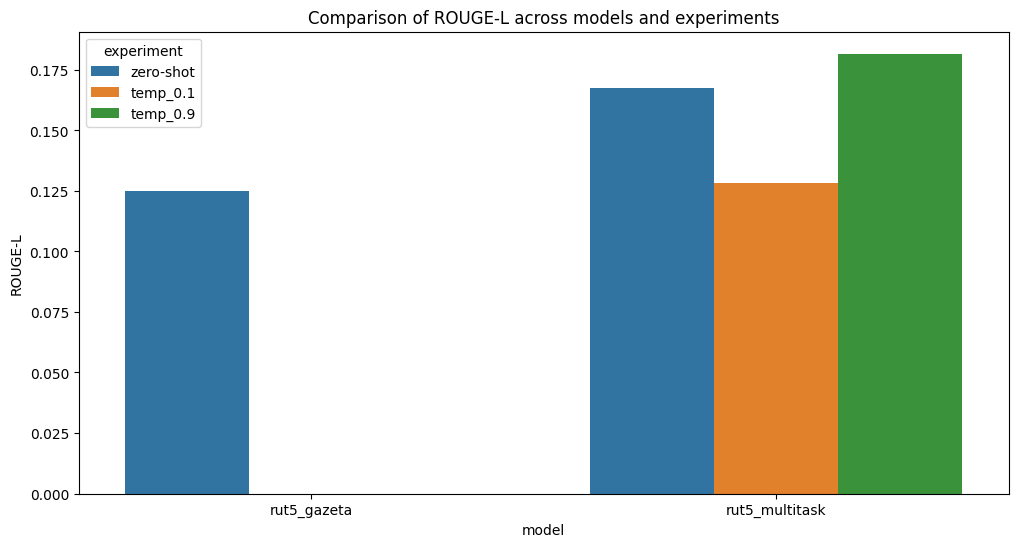

In [27]:
# 10. Сбор и визуализация результатов
df_results = pd.DataFrame(results)

# Группируем для сравнительной таблицы
summary_table = df_results.groupby(["model", "experiment"])[["ROUGE-1", "ROUGE-L", "BLEU", "BERTScore", "duration"]].mean()
print(summary_table)

# Визуализация
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x="model", y="ROUGE-L", hue="experiment")
plt.title("Comparison of ROUGE-L across models and experiments")
plt.show()

In [28]:
# 11. Анализ ошибок
# Добавим поколоночный BERTScore в dataframe
# (В функции выше мы усредняли, нужно бы пересчитать индивидуально если хотим точный топ)
# Но для демо просто выведем примеры из таблицы

print("Примеры генераций (Zero-shot):")
for i in range(3):
    print(f"--- example {i} ---")
    res = df_results[(df_results["model"]=="rut5_gazeta") & (df_results["experiment"]=="zero-shot")].iloc[i]
    print(f"Reference: {res['reference']}")
    print(f"Prediction: {res['prediction']}")
    print()


Примеры генераций (Zero-shot):
--- example 0 ---
Reference: Протестующие против антикоронавирусных мер немцы скандировали имя российского президента, потому что уважают его. Такое мнение выразил депутат городской палаты представителей Гуннар Линдеманн. На этих выходных в Берлине прошли крупные акции протеста. Манифестанты требовали отменить ношение масок и отказаться от соблюдения безопасного расстояния в 1,5 м друг от друга.
Prediction: В Берлине прошли массовые акции протеста против введенных для борьбы с коронавирусом ограничений. По словам депутата городской палаты представителей Гуннара Линдеманна, демонстранты скандировали фамилию российского президента из уважения к нему. По его словам, протестующие ранее пришли к российскому посольству, чтобы «привлечь внимание к условиям в Германии», надеясь, что Россия сможет оказать влияние на канцлера ФРГ Ангелу Меркель.

--- example 1 ---
Reference: Делегации Израиля и США прилетели в ОАЭ, где обсудили с руководством страны ряд вопросов в 